# Ensemble validation

The 5 parameter sets calculkated in Calibration_HBV.ipynb will be used for a validation period, in which the log NSE will be calculated, a mean will be calculated and total low flow days during the navigation season.

The structure of this notebook is as follows:

### 1. Startup
### 2. Model Setup
### 3. Running model
### 4. LNSE calculation
### 5. Display results
### 6. Lowflow calculation

## 1. Startup

In [2]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

In [3]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [4]:
# Defining things

basin_size = 132572
q_critical = 500

In [5]:
# Choosing time period

experiment_start_date = "2019-01-01T00:00:00Z"
experiment_end_date = "2024-12-31T00:00:00Z"

validation_start = "1999-01-01T00:00:00Z"
validation_end = "2009-12-31T00:00:00Z"

In [6]:
# Create pathways for ERA 5 forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "ERA5-1999-2009"

discharge_file = Path.home() / "BEP-maxime" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [7]:
# # Create pathways for ERA 5 forcings

# forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "forcings" / "ERA5-1999-2019"

# discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

# shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "Shapefiles" / "07DA001_basin.shp"

# hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
# hbv_config.mkdir(parents=True, exist_ok=True)

In [8]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [9]:
# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

# Align q_obs to relevant dates
q_obs = q_obs[(q_obs["Date"] >= validation_start_date) & (q_obs["Date"] <= validation_end_date)]
observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

In [10]:
observed_output.head()

Date
1999-01-01    104.0
1999-01-02    103.0
1999-01-03    101.0
1999-01-04    103.0
1999-01-05    105.0
Name: Observed discharge, dtype: float64

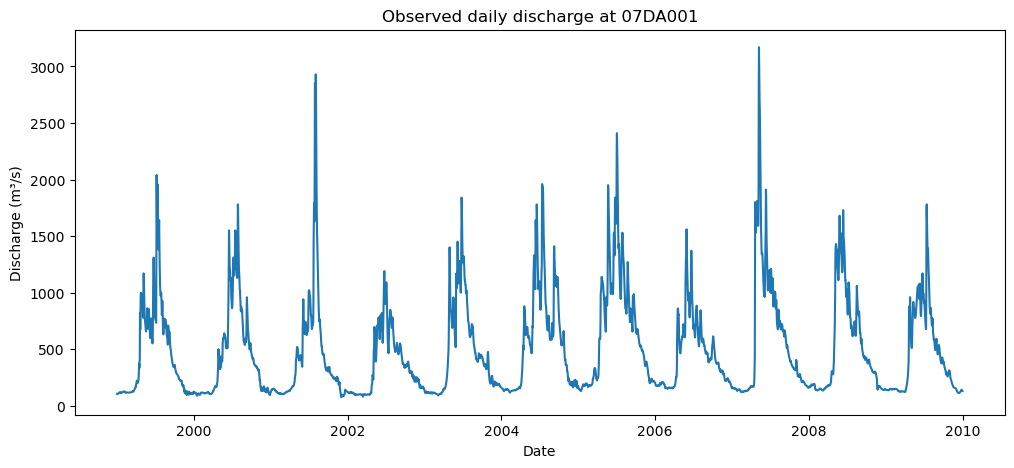

In [11]:
# Plot q_obs

plt.figure(figsize=(12, 5))
plt.plot(q_obs["Date"], q_obs["discharge_m3s"])

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Observed daily discharge at 07DA001")

plt.show()

### Generate/Load CMIP6 data

In [13]:
# Generate data
CMIP_dataset = {'dataset': 'MPI-ESM1-2-HR', 'project': 'CMIP6', 'grid' : 'gn', 'exp': 'historical', 'ensemble': 'r1i1p1f1'}

CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
    dataset=CMIP_dataset,
   start_time=validation_start,
   end_time=validation_end,
   shape=shape_file,
)

# Load data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1999-01-01T00:00:00Z',
    end_time='2009-12-31T00:00:00Z',
    directory=PosixPath('/home/maxime/BEP-maxime/Workyard/forcings/ERA5-1999-2009'),
    shape=PosixPath('/home/maxime/BEP-maxime/Workyard/Shapefiles/07DA001_basin.shp'),
    filenames={
        'evspsblpot': 'combined_ERA5_1999_2009_evspsblpot.nc',
        'pr': 'combined_ERA5_1999_2009_pr.nc',
        'rsds': 'combined_ERA5_1999_2009_rsds.nc',
        'tas': 'combined_ERA5_1999_2009_tas.nc'
    }
)

### Load parameter sets & initial storages

In [55]:
# Load calibration constants

# par_0 = [4.45787, 0.42307, 201.57602, 2.36497, 0.26755, 8.62964, 0.083568, 0.0037073, 0.29645]
# par_0 = [2.79874, 0.49211, 255.96478, 1.782968, 0.503199, 6.095956, 0.33279, 0.10539, 0.63857]
# par_0 = [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606]         # 0.725 val, 0.x cal - Fav run 2
# par_0 = [6.28908, 0.423917, 173.56627, 1.63144, 0.402586, 6.56151, 0.0456809, 0.00313744, 0.516696]                 # 0.702 val, 0.x cal
# par_0 = [6.4919, 0.386877, 221.78625, 1.388269, 0.276453, 4.9870704, 0.04126777, 0.05640195, 1.148877]              # 0.668 val, 0.x cal
# par_0 = [7.502398, 0.38028, 194.1899, 1.680197, 0.47956, 4.8566806, 0.041745354, 0.02833896, 1.051862]              # 0.677 val, 0.x cal
# par_0 = [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392]                        # 0.781 val, 0.776 cal
# par_0 = [6.16512, 0.4369419, 151.2515900, 1.727835, 0.3771705, 6.19265974, 0.06959136, 0.001310818, 0.8130732]      # 0.664 val, 0.791 cal
# par_0 = [5.7107, 0.441634, 172.81305, 1.87367, 0.588802, 5.498147, 0.060305, 0.019666, 1.2011814]                    # x val, 0.73 cal         Start of 5+ months exclusion
# par_0 = [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504]                    # 0.82 val, 0.818 cal - Fav run 1      
# par_0 = [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]                    #  val,  0.77 cal    
# par_0 = [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857]                           # 0.78 val, 0.71 cal - potential inclusion

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]
]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"          # Snowmelt factor
               ]

# Initial: par_0 = [5.085, 0.55, 100.373, 1.612, 0.545, 3.801, 0.196, 0.00, 0.185]

In [56]:
# Storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

## 2. Model setup

In [57]:
def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config
    )

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge"
    )

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

## 3. Running model

In [58]:
def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing
        )

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Filter observed data by day
    observed_daily = observed_output
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)
    ensemble_data['Observed discharge'] = observed_daily

    return ensemble_data

In [60]:
ensemble_data_ERA5 = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=ERA5_forcing
)

ensemble_data_CMIP = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=CMIP_forcing
)

ensemble_data_ERA5.head()
ensemble_data_CMIP.head()

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

...

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

,Set 1,Set 2,Set 3,Set 4,Set 5,Mean,Observed discharge
1999-01-02,0.0,0.0,0.0,0.0,0.0,0.0,103.0
1999-01-03,0.0,0.0,0.0,0.0,0.0,0.0,101.0
1999-01-04,0.0,0.0,0.0,0.0,0.0,0.0,103.0
1999-01-05,0.0,0.0,0.0,0.0,0.0,0.0,105.0
1999-01-06,0.0,0.0,0.0,0.0,0.0,0.0,108.0


## 4. LNSE Calculation

In [61]:
# Calculate log NSE

def LNSE(sim, obs):
    
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    # Avoid log(0)
    eps = 0.00000000001

    log_sim = np.log(sim + eps)
    log_obs = np.log(obs + eps)

    return 1 - np.sum((log_obs - log_sim) ** 2) / np.sum((log_obs - np.mean(log_obs)) ** 2)

In [62]:
# Call log NSE for relevant timeperiod

def lnse_ensemble(ensemble_data, lnse_start, lnse_end):

    # Select evaluation period - skip first year for storages to fill
    combined_data = ensemble_data[
        (ensemble_data.index >= lnse_start) &
        (ensemble_data.index <= lnse_end)
    ].dropna()

    # Exclude winter months
    combined_data = combined_data[
        ~combined_data.index.month.isin([12, 1, 2, 3, 4])
    ]

    lnse_results = []

    # Calculate LNSE for all sets
    for i in range(len(par_ensemble)):
        lnse_value = LNSE(
            combined_data[f"Set {i+1}"],
            combined_data["Observed discharge"]
        )

        # Append LNSE
        lnse_results.append({
            "Set": f"Set {i+1}",
            "LNSE": lnse_value
        })

    # Calculate LNSE of ensemble mean
    mean_lnse = LNSE(
        combined_data["Mean"],
        combined_data["Observed discharge"]
    )

    # Append LNSE
    lnse_results.append({
        "Set": "Ensemble mean",
        "LNSE": mean_lnse
    })

    lnse_results = pd.DataFrame(lnse_results)

    return lnse_results

In [91]:
lnse_results_ERA5 = lnse_ensemble(
    ensemble_data=ensemble_data_ERA5,
    lnse_start=evaluation_start,
    lnse_end=validation_end_date
)

lnse_results_CMIP = lnse_ensemble(
    ensemble_data=ensemble_data_CMIP,
    lnse_start=evaluation_start,
    lnse_end=validation_end_date
)

lnse_results_ERA5


,Set,LNSE
0,Set 1,0.677691
1,Set 2,0.689680
2,Set 3,0.696169
3,Set 4,0.642352
4,Set 5,0.643318
5,Ensemble mean,0.725469


## 5. Display results

In [67]:
def plot_ensemble(ensemble_data, plot_start, plot_end):

    plot_start = pd.to_datetime(plot_start)
    plot_end = pd.to_datetime(plot_end)

    # Filter data to start & end time
    plot_data = ensemble_data[
        (ensemble_data.index >= plot_start) &
        (ensemble_data.index <= plot_end)
    ].dropna()

    # Define figure
    plt.figure()
    plt.figure(figsize=(20, 8))

    # Plot sets, observed data, ensemble mean and axhline, respectively
    for i in range(len(par_ensemble)):
        plt.plot(plot_data.index, plot_data[f"Set {i+1}"], color="orange", alpha=0.3, label="Parameter sets" if i == 0 else None)

    plt.plot(plot_data.index, plot_data["Observed discharge"], label="Observed discharge", linewidth=3)
    plt.plot(plot_data.index, plot_data["Mean"], label="Ensemble mean", linewidth=3)
    plt.axhline(y=q_critical, linestyle=":", color="black", label=f"Critical discharge ({q_critical} m³/s)")

    # Extras
    plt.xlabel("Date")
    plt.ylabel("Discharge (m³/s)")
    plt.title("Observed vs modelled ensemble discharge at 07DA001")
    plt.legend()
    plt.grid(True)

    plt.show()

<Figure size 640x480 with 0 Axes>

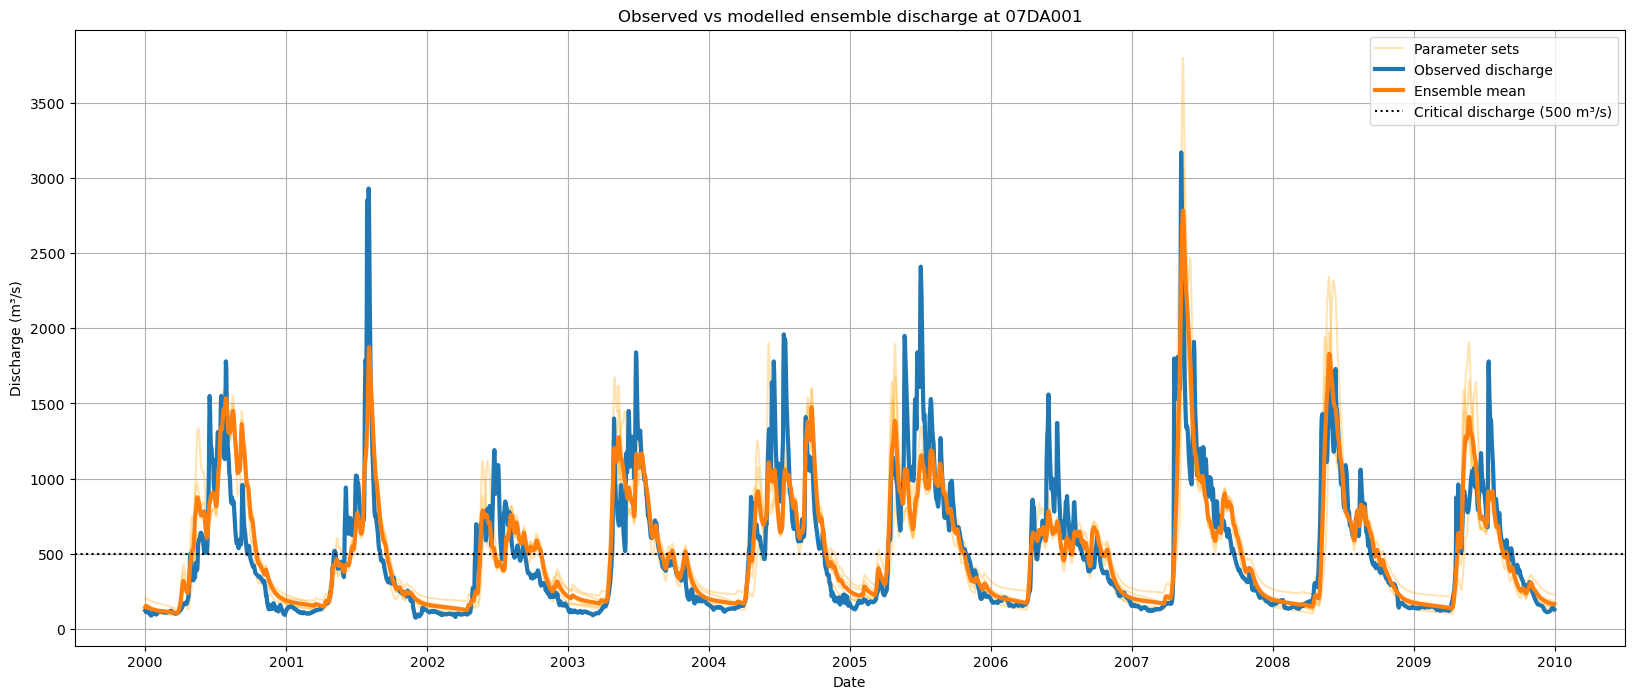

<Figure size 640x480 with 0 Axes>

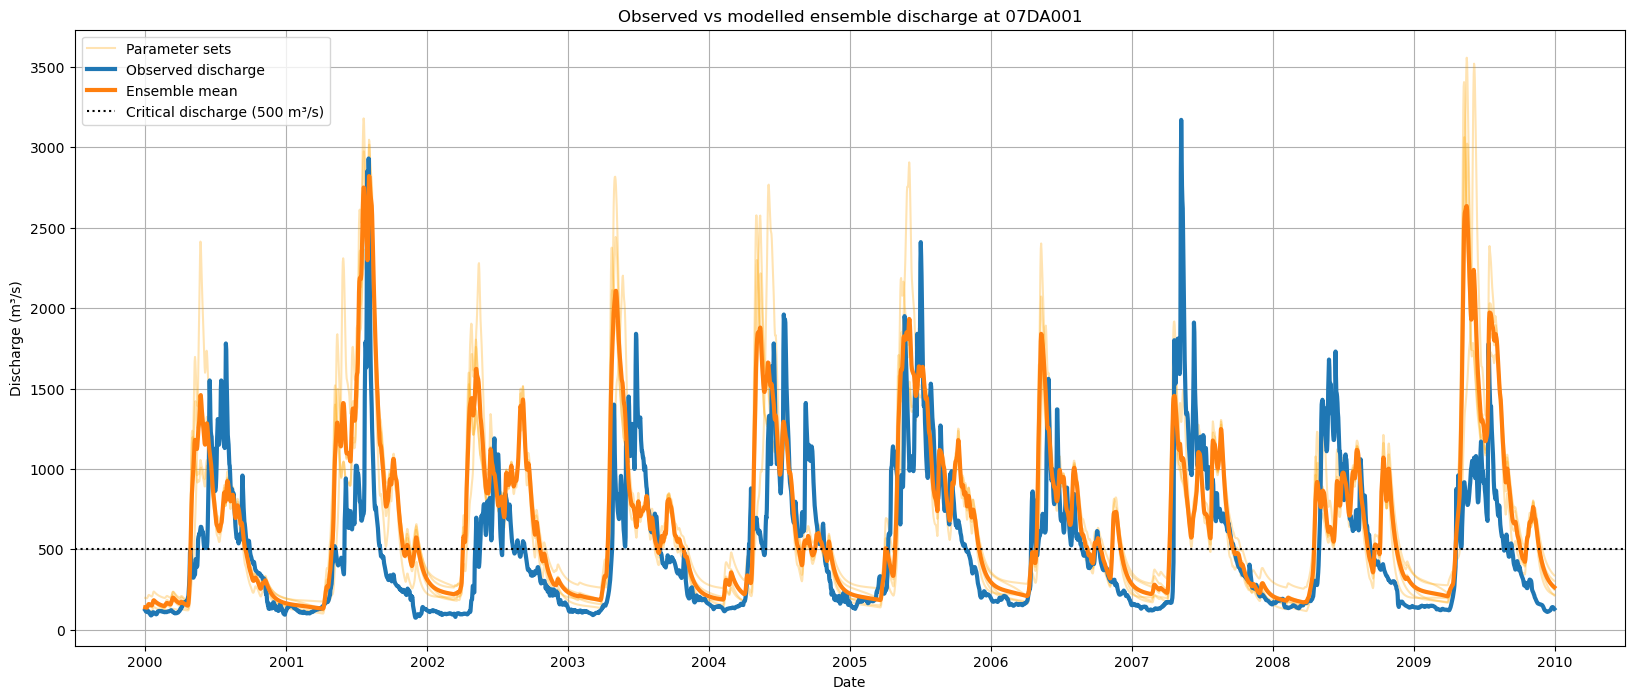

In [69]:
# Plot for full evaluation period

plot_ensemble_ERA5 = plot_ensemble(
    ensemble_data=ensemble_data_ERA5,
    plot_start=evaluation_start,
    plot_end=validation_end_date
)

plot_ensemble_CMIP = plot_ensemble(
    ensemble_data=ensemble_data_CMIP,
    plot_start=evaluation_start,
    plot_end=validation_end_date
)

<Figure size 640x480 with 0 Axes>

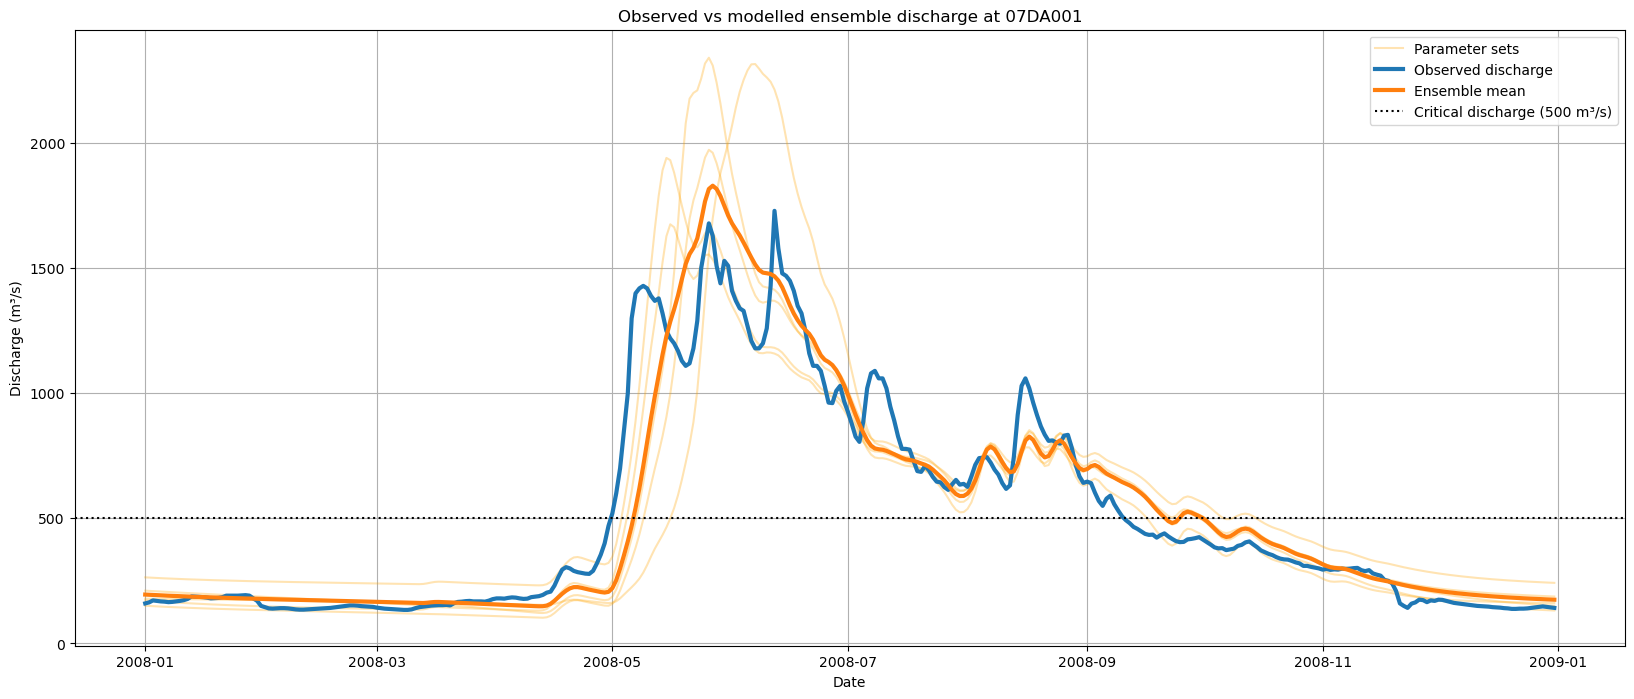

<Figure size 640x480 with 0 Axes>

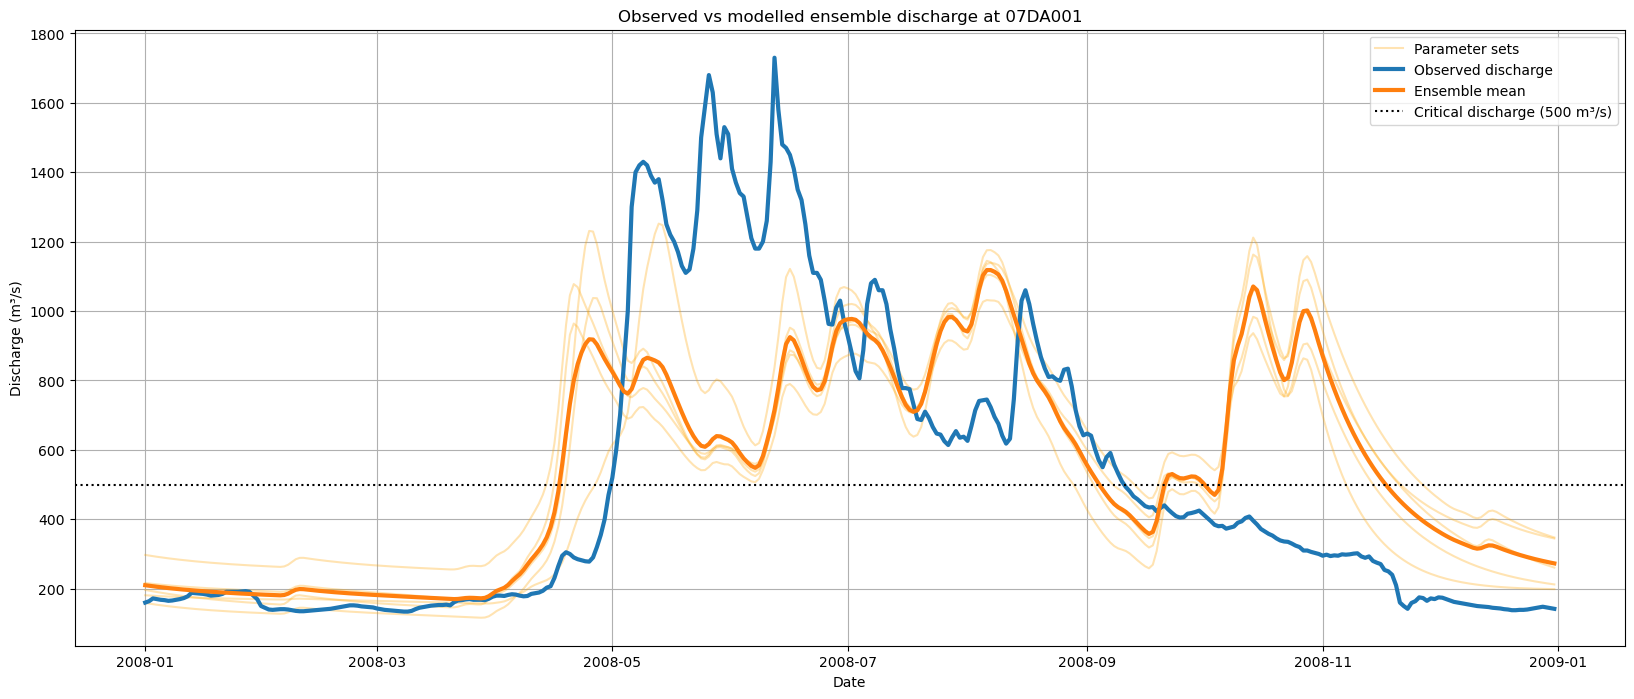

In [111]:
# Plot for selected year

selected_year = 2008

plot_ensemble(
    ensemble_data=ensemble_data_ERA5,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31")
)

plot_ensemble(
    ensemble_data=ensemble_data_CMIP,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31")
)

## 6. Lowflow calculation

In [80]:
def lowflow_counter_ensemble(ensemble_data, start_date, end_date):
    
    lowflow_days = []

    years = list(range(start_date.year, end_date.year + 1))

    for i in range(len(years)):
    
        year = years[i]
    
        # Define start and end month-day
        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")
    
        year_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)
        ]

        # Set zeros to count from
        observed_lowflow_days = 0
        modelled_lowflow_days = []
        modelmean_lowflow_days = 0

        # Count observed lowflow days
        for j in range(len(year_data)):

            observed_q = year_data.iloc[j]["Observed discharge"]

            if observed_q < q_critical:
                observed_lowflow_days += 1

        # Count model mean lowflow days
        for j in range(len(year_data)):

            modelmean_q = year_data.iloc[j]["Mean"]

            if modelmean_q < q_critical:
                modelmean_lowflow_days += 1

        # Count modelled lowflow days
        for j in range(len(par_ensemble)):

            set_lowflow_days = 0

            for k in range(len(year_data)):

                set_q = year_data.iloc[k][f"Set {j+1}"]

                if set_q < q_critical:
                    set_lowflow_days += 1

            modelled_lowflow_days.append(set_lowflow_days)

        setavg_lowflow_days = np.mean(modelled_lowflow_days)
        
        lowflow_days.append({
            "year": year,
            "observed": observed_lowflow_days,
            "modelmean": modelmean_lowflow_days,
            "set_1": modelled_lowflow_days[0],
            "set_2": modelled_lowflow_days[1],
            "set_3": modelled_lowflow_days[2],
            "set_4": modelled_lowflow_days[3],
            "set_5": modelled_lowflow_days[4],
            "set_avg": np.round(setavg_lowflow_days)
        })

    lowflow_days = pd.DataFrame(lowflow_days)

    return lowflow_days

In [90]:
# lowflow_counter_ensemble(
#     ensemble_data=ensemble_data_ERA5,
#     start_date=evaluation_start,
#     end_date=validation_end_date
# )

lowflow_counter_ensemble(
    ensemble_data=ensemble_data_CMIP,
    start_date=evaluation_start,
    end_date=validation_end_date
)

,year,observed,modelmean,set_1,set_2,set_3,set_4,set_5,set_avg
0,2000,20,31,36,28,29,29,28,30.0
1,2001,60,0,0,0,0,0,0,0.0
2,2002,52,0,8,0,0,0,0,2.0
3,2003,51,6,21,0,7,9,0,7.0
4,2004,5,23,41,17,27,31,0,23.0
5,2005,0,0,0,0,0,0,0,0.0
6,2006,42,24,40,20,31,29,0,24.0
7,2007,25,26,42,15,29,31,7,25.0
8,2008,37,21,38,18,23,23,6,22.0
9,2009,42,13,23,8,14,16,0,12.0
